# Advection equation

Advection describes the transport of a substance or quantity by bulk motion. The advection equation is described mathematically as:

$$
\frac{\partial \phi}{\partial t} + \nabla \cdot (\mathbf{u} \phi) = 0
$$

where $\mathbf{u}$ is the transportation velocity field and $\phi$ is the quantity being transported.

In this notebook, we consider a simple case where the velocity field is a constant vector in spatial dimensions. This simplifies the equation to:

$$
\frac{\partial \phi}{\partial t} + \mathbf{u} \cdot \nabla \phi = 0
$$

## Solution in 1D

In [1]:
from torchfsm.operator import LinearAdvection
# If your velocity is not constant in space, you can use the `Advection` operator.
advection=-1*LinearAdvection(0.1)

In [2]:
import torch
from torchfsm.mesh import MeshGrid
from torchfsm.plot import plot_traj
from torchfsm.traj_recorder import AutoRecorder
device='cuda' if torch.cuda.is_available() else 'cpu'
L=1.0; N=128; 

In [3]:
mesh=MeshGrid([(0,L,N)],device=device)
x=mesh.bc_mesh_grid()
u_0=torch.sin(2*torch.pi*x/L)+0.5
traj=advection.integrate(
    u_0=u_0,
    mesh=mesh,
    dt=0.1,
    step=200,
    trajectory_recorder=AutoRecorder(),
)

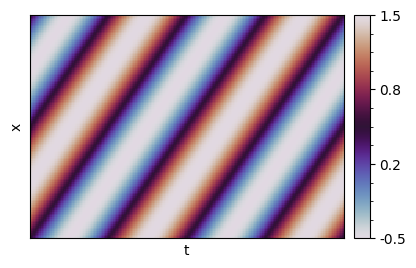

In [4]:
plot_traj(traj,animation=False,use_sym_colormap=False)

## Solution in 2D

In [5]:
mesh=MeshGrid([(0,L,N),(0,L,N)],device=device)
x,y=mesh.bc_mesh_grid()
u_0=torch.sin(2*torch.pi*x/L)*torch.cos(4*torch.pi*y/L)
traj=advection.integrate(
    u_0=u_0,
    mesh=mesh,
    dt=0.1,
    step=50,
    trajectory_recorder=AutoRecorder(),
)

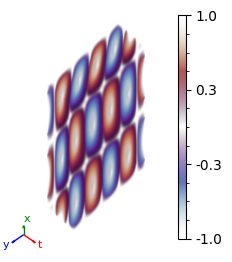

In [6]:
plot_traj(traj,animation=False)

## Solution in 3D

In [7]:
mesh=MeshGrid([(0,L,N),(0,L,N),(0,L,N)],device=device)
x,y,z=mesh.bc_mesh_grid()
u_0=torch.sin(2*torch.pi*x/L)*torch.cos(4*torch.pi*y/L)*torch.sin(6*torch.pi*z/L)
traj=advection.integrate(
    u_0=u_0,
    mesh=mesh,
    dt=0.1,
    step=50,
    trajectory_recorder=AutoRecorder(),
)

In [8]:
plot_traj(traj)